Código para replicar la generación guardada del algoritmo genético. Guardar convergencia de cada evaluación y el último frente

In [2]:
import numpy as np
import matplotlib.pyplot as plt
X_txt = 'X_ruta_larga_M9_300gen_400pop.txt'
X =  np.loadtxt(X_txt)
convergence_txt = 'Convergencia_ruta_larga_M9_300gen_400pop.txt'
convergence = np.loadtxt(convergence_txt)

In [3]:
convergence.shape

(300, 3)

In [4]:
X.shape

(351, 24)

In [5]:
import os
from scipy.io import loadmat
# Ruta del archivo que se quiera cargar
home_dir = os.path.expanduser("~")
DataSimCianos = os.path.join(home_dir, "Desktop", "Spline Optimizer", "Saves", "simulationSol-E9.mat")

# Cargar el archivo MAT
data = loadmat(DataSimCianos)  # Aquí cargamos el archivo realmente

# Mostrar las claves (variables almacenadas en el archivo)
#print(data.keys())

# Acceder a una tabla específica por su clave (reemplaza 'nombre_tabla' por la clave real)
IDLogs = data["IDLog"] #Dimensiones: [instantes de tiempo x nº máx de partículas en algún instante] ej: [187x612]
#print("Tabla IDLogs: \n", IDLogs) 
parentCell = data["parentCell"] #Dimensiones: [1 x nº total de partículas que aparecen en la simulación] ej: [1x1261]
#print("Tabla parentCell: \n", parentCell)
tVec = data["tVec"] #Dimensiones [1 x instantes de tiempo] ej: [1x187]
#tVec está en dias, lo pasamos a minutos
tVec_min = tVec*24*60
#print("Tabla tVec", tVec)
xCellLog = data["xCellLog"] #Dimensiones [instantes de tiempo x nº máximo de partículas en algún instante x (x, y, z)] ej: [187x612x3]
#print("Tabla xCellLog: \n", xCellLog)


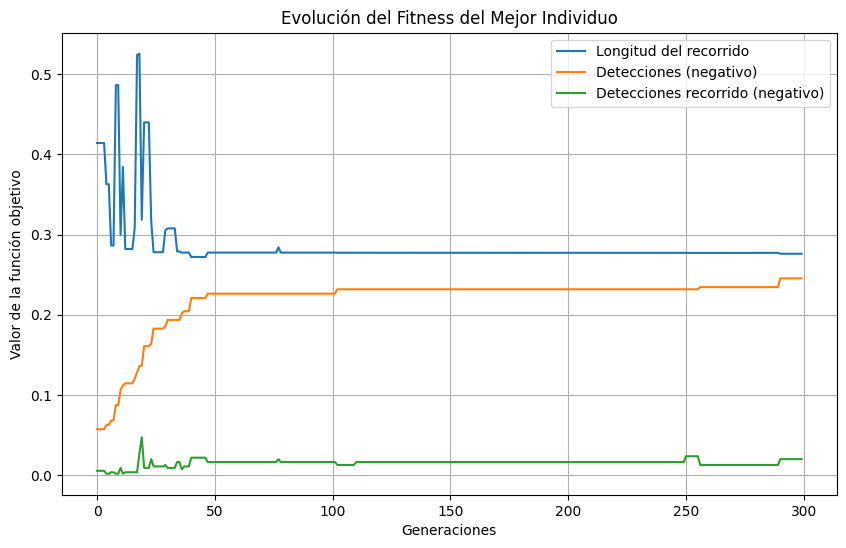

In [6]:

# Crear la gráfica
plt.figure(figsize=(10, 6))

plt.plot(convergence[:, 0], label="Longitud del recorrido")
plt.plot(-convergence[:, 1], label="Detecciones (negativo)")
plt.plot(-convergence[:, 2], label="Detecciones recorrido (negativo)")

plt.xlabel("Generaciones")
plt.ylabel("Valor de la función objetivo")
plt.title("Evolución del Fitness del Mejor Individuo")
plt.legend()
plt.grid()
plt.show()

In [7]:
def calcular_distancia(p1, p2):
    return np.sqrt((p1[0]-p2[0])**2+(p1[1]-p2[1])**2)

# def eliminar_particulas_en_rango(mapa, centro, rango_deteccion, indices_detectados, indices_eliminadas):
#     # Convertir centro en array numpy
#     centro = np.array(centro[:2])
    
#     # Inicializar distancias con un valor alto
#     distancias = np.full(mapa.shape[0], 9999.675)  
    
#     # Filtrar solo los valores válidos
#     mascara_validas = (indices_eliminadas == 0)
#     mascara_detectadas = (indices_eliminadas == 1)
    
#     #print(f"Distancias shape antes = {distancias.shape}")  # Debe ser (550,)
    
#     # Calcular solo para las partículas válidas
#     distancias[mascara_validas] = np.linalg.norm(mapa[mascara_validas, :2] - centro[:2], axis=1)
    
#     #print(f"Distancias shape después = {distancias.shape}")  # Debe seguir siendo (550,)
    
#     # Aplicar lo mismo para distancias_repetidas
#     distancias_repetidas = np.full(mapa.shape[0], 9999.675)
#     distancias_repetidas[mascara_detectadas] = np.linalg.norm(mapa[mascara_detectadas, :2] - centro[:2], axis=1)

#     #print(f"Mapa shape = {mapa.shape}")  # (550, 3)
    
#     # Encontrar las partículas dentro del rango de detección
#     indices_detectados[mascara_validas] = (distancias[mascara_validas] <= rango_deteccion).astype(int)
#     indices_eliminadas[mascara_validas] = (distancias[mascara_validas] <= rango_deteccion*3).astype(int)
    
#     #print(f"indices_detectados shape = {indices_detectados.shape}")  # (550,)
    
#     # Imprimir solo las distancias menores al rango de detección
#     #print(distancias[indices_detectados.astype(bool)])
    
#     return indices_detectados, indices_eliminadas

In [8]:

def eliminar_particulas_en_rango(mapa, centro, rango_deteccion, indices_detectados, indices_eliminadas):
    # Convertir centro en array numpy
    centro = np.array(centro[:2])
    
    # Inicializar distancias con un valor alto
    distancias = np.full(mapa.shape[0], 9999.675)  
    
    # Filtrar solo los valores válidos
    mascara_validas = (indices_eliminadas == 0)
    mascara_detectadas = (indices_eliminadas == 1)
    
    #print(f"Distancias shape antes = {distancias.shape}")  # Debe ser (550,)
    
    # Calcular solo para las partículas válidas
    distancias[mascara_validas] = np.linalg.norm(mapa[mascara_validas, :2] - centro[:2], axis=1)
    
    #print(f"Distancias shape después = {distancias.shape}")  # Debe seguir siendo (550,)
    
    # Aplicar lo mismo para distancias_repetidas
    distancias_repetidas = np.full(mapa.shape[0], 9999.675)
    distancias_repetidas[mascara_detectadas] = np.linalg.norm(mapa[mascara_detectadas, :2] - centro[:2], axis=1)

    #print(f"Mapa shape = {mapa.shape}")  # (550, 3)
    
    # Encontrar las partículas dentro del rango de detección
    indices_detectados[mascara_validas] = (distancias[mascara_validas] <= rango_deteccion).astype(int)
    indices_eliminadas[mascara_validas] = (distancias[mascara_validas] <= rango_deteccion*3).astype(int)
    
    #print(f"indices_detectados shape = {indices_detectados.shape}")  # (550,)
    
    # Imprimir solo las distancias menores al rango de detección
    #print(distancias[indices_detectados.astype(bool)])
    
    return indices_detectados, indices_eliminadas


In [17]:
F

array([[ 0.14323953, -0.03      , -0.09090909],
       [ 0.18125397, -0.10636364, -0.08363636],
       [ 0.13430706, -0.02454545, -0.08545455],
       ...,
       [ 0.10086506, -0.19636364, -0.02181818],
       [ 0.12598423, -0.22909091, -0.03636364],
       [ 0.09450718, -0.03      , -0.01818182]])

In [18]:
#Obtener el fitness de la última generación
n_objs = 3
F = np.zeros((len(X), n_objs))
print(F.shape)
mapa_particulas = np.copy(xCellLog)
v_media = 1 #m/s
rango_deteccion = 5 #m
indice_tVec_ant = 0
n_puntos = 17
xl = np.array([-600, -400, -20])
xu = np.array([600, 200, 0])
max_dist = 100000
for j in range(len(X)):
    x = X[j]
    # x contiene los índices de las partículas ordenadas para el recorrido
    recorrido = [x[w:w+3] for w in range(0, len(x), 3)]
    # print(len(recorrido))
    # Longitud total del recorrido
    longitud_recorrido = 0
    mov=0
    detecciones_totales = 0
    repetidas_totales = 0
    tiempo=tVec_min[0,0] #Tomamos como orgien el tiempo inicial de la simulación
    indices_detectados = np.zeros(len(mapa_particulas[1]))
    indices_repetidas = np.zeros(len(mapa_particulas[1])) 
    indices_eliminadas = np.zeros(len(mapa_particulas[1]))
    t_medida_ant = 8 #min
    detecciones_recorrido = 0
    # Iterar sobre el recorrido y calcular la longitud total
    #print(recorrido)
    for i in range(len(recorrido)):
        deteccion = 0
        if (i==0):
            p2 = recorrido[i]
        else:
            p1 = recorrido[i-1]
            p2 = recorrido[i]
            longitud_recorrido += calcular_distancia(p1, p2)
            #print(longitud_recorrido)
    
        tAct = tiempo + longitud_recorrido/(v_media*60)+t_medida_ant*(i+1) #El i+i es para sumar el tiempo de cada vez que se ha medido
        dif_tVec_tAct = np.abs(tVec_min - tAct) #Hacemos el absoluto para buscar el 0, es decir, el más cercano al instante actual
        indice_tVec = np.argmin(dif_tVec_tAct) #El índice que tengo que buscar en 
        
        #print(f"tAct: {tAct}, tVec: {tVec_min}")
        #print(f"Diferencia absoluta: {dif_tVec_tAct}")
        #print(f"Índice del valor más cercano: {indice_tVec}")
        
        #Hay que ver si en el cambio de tVec se han modificado los ID detectados. 
        #Para ello simplemente creamos un nuevo indices_detectados en caso de que haya cambiado el mapa actualizando las posiciones de los nuevos indices
        if(indice_tVec != indice_tVec_ant):
            #Creamos un diccionario de detecciones
            id_detectados = {id_: det for id_, det in zip(IDLogs[indice_tVec_ant], indices_detectados) if not np.isnan(id_)}
            id_detectados_t2 = np.array([id_detectados.get(id_, 0) for id_ in IDLogs[indice_tVec]])
            indices_detectados = (id_detectados_t2 > 0).astype(int)
        # Actualizar el mapa y contar las partículas detectadas

        #Esto es en caso de que se quiera tener en cuenta el número de partículas que se detectan en el recorrido. Si no se quiere tener en cuenta 
        #comentar esta parte (desde el if j != 0 hasta el detecciones_recorrido += 1) y descomentar el otro F[j]

        indices_detectados, indices_eliminadas = eliminar_particulas_en_rango(xCellLog[indice_tVec, :, :], p2, rango_deteccion, indices_detectados, indices_eliminadas)
        
        if i != 0:
            for i in range(len(recorrido)):
                if i != 0:
                    p1, p2 = recorrido[i-1], recorrido[i]
                
                    # Definir la elipse
                    a = calcular_distancia(p1, p2) / 2  # Semieje mayor (mitad del segmento)
                    #b = min(problema.rango_deteccion, a)  # Semieje menor (máximo hasta el radio de detección)
                    b = 0.05
                    centro_elipse = (np.array(p1) + np.array(p2)) / 2  # Centro de la elipse
                
                    particulas_en_elipse = 0
                    for particula in xCellLog[indice_tVec, :, :]:
                        # Ecuación de la elipse: ((x - h)^2 / a^2) + ((y - k)^2 / b^2) <= 1
                        if ((particula[0] - centro_elipse[0])**2 / a**2 + (particula[1] - centro_elipse[1])**2 / b**2) <= 1:
                            particulas_en_elipse += 1
                
                    detecciones_recorrido += particulas_en_elipse
                    
        
    
        indice_tVec_ant = indice_tVec
        detecciones_totales = np.sum(indices_detectados)
        #print(detecciones_totales)
        # Definir la función objetivo: minimizar la longitud y maximizar las detecciones
        #F[j] = [longitud_recorrido/(n_puntos*calcular_distancia(xl, xu)), -1.5*detecciones_totales/mapa_particulas.shape[1]]  # Usamos -detecciones_totales para maximizar. Normalizamos las detecciones con el n máx de partículas y la longitud con la longitud máxima de la población
        F[j] = [longitud_recorrido/(n_puntos*calcular_distancia(xl, xu)), -1.5*detecciones_totales/mapa_particulas.shape[1], -detecciones_recorrido/mapa_particulas.shape[1]]

(351, 3)


In [21]:
best_idx = np.argmin(F[:, 2])  # Encuentra el índice del menor valor en la columna 1
mejor_individuo = X[best_idx]  # Extrae la solución correspondiente

# weights = np.array([0.5, 0.5])  # Ajusta según tus preferencias
# scores = (F * weights).sum(axis=1)  # Calcula la función agregada
# best_idx = np.argmin(scores)  # Minimización
# mejor_individuo = X[best_idx]

print(f"best_idx = {best_idx}")

#====== Si se quieren poner umbrales ======# 
# filtered_idx = np.where((F[:, 0] <= 0.5) & (F[:, 1] <= 0.3))[0]
# best_idx = filtered_idx[np.argmin(F[filtered_idx, 2])]  # Minimiza el tercer objetivo
# best_solution = pop[best_idx]
#=========================================#

#Ahora saco la evolución de las detecciones al igual que en la evaluacion
# Iterar sobre el recorrido y calcular la longitud total
for i in range(2, len(mejor_individuo), 3):
    #print(i)
    mejor_individuo[i]=-15

recorrido = [mejor_individuo[i:i+3] for i in range(0, len(mejor_individuo), 3)]

tiempo=tVec_min[0,0] #Tomamos como orgien el tiempo inicial de la simulación
indices_detectados = np.zeros(len(mapa_particulas[1]))
indices_detectados_ant = np.zeros(len(mapa_particulas[1]))
indices_eliminadas = np.zeros(len(mapa_particulas[1]))
pesos_gaussianos_i =  np.zeros(len(mapa_particulas[1]))
aportaciones = np.zeros(len(mapa_particulas[1]))
indices_repetidas = np.zeros(len(mapa_particulas[1])) 
longitud_recorrido = 0
mapa_dinamico_detecciones = np.zeros((len(recorrido), len(indices_detectados)))
detecciones_totales = 0
t_medida = 8 #min
for i in range(len(recorrido)):
    deteccion = 0
    if (i==0):
        p2 = recorrido[i]
    else:
        p1 = recorrido[i-1]
        p2 = recorrido[i]
        longitud_recorrido += calcular_distancia(p1, p2)

    tAct = tiempo + longitud_recorrido/(v_media*60)+t_medida*(i+1) #El i+i es para sumar el tiempo de cada vez que se ha medido
    dif_tVec_tAct = np.abs(tVec_min - tAct) #Hacemos el absoluto para buscar el 0, es decir, el más cercano al instante actual
    indice_tVec = np.argmin(dif_tVec_tAct) #El índice que tengo que buscar en 
    
    #print(f"tAct: {tAct}, tVec: {tVec_min}")
    #print(f"Diferencia absoluta: {dif_tVec_tAct}")
    #print(f"Índice del valor más cercano: {indice_tVec}")
    
    #Hay que ver si en el cambio de tVec se han modificado los ID detectados. 
    #Para ello simplemente creamos un nuevo indices_detectados en caso de que haya cambiado el mapa actualizando las posiciones de los nuevos indices
    if(indice_tVec != indice_tVec_ant):
        #Creamos un diccionario de detecciones
        id_detectados = {id_: det for id_, det in zip(IDLogs[indice_tVec_ant], indices_detectados) if not np.isnan(id_)}
        id_detectados_t2 = np.array([id_detectados.get(id_, 0) for id_ in IDLogs[indice_tVec]])
        indices_detectados = (id_detectados_t2 > 0).astype(int)
    # Actualizar el mapa y contar las partículas detectadas
    
    indices_detectados, indices_eliminadas = eliminar_particulas_en_rango(xCellLog[indice_tVec, :, :], p2, rango_deteccion, indices_detectados, indices_eliminadas)

    indice_tVec_ant = indice_tVec
    mapa_dinamico_detecciones[i] = indices_detectados
    #print(f"Indices detectados = {np.sum(indices_detectados)}")
detecciones_totales = np.sum(indices_detectados)
#print(f"Detecciones totales = {detecciones_totales}")
#print(f"Tiempo total = {(tAct-tiempo)*60}")

best_idx = 0



Mapa número = 0


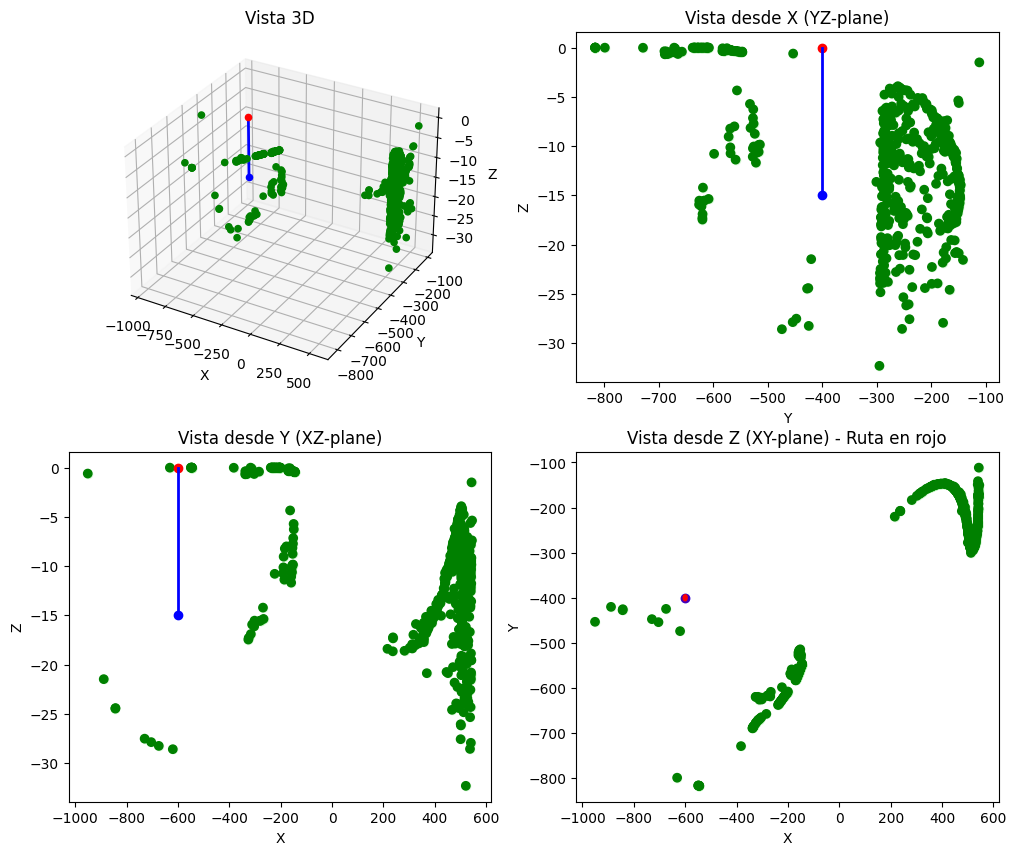


Mapa número = 1


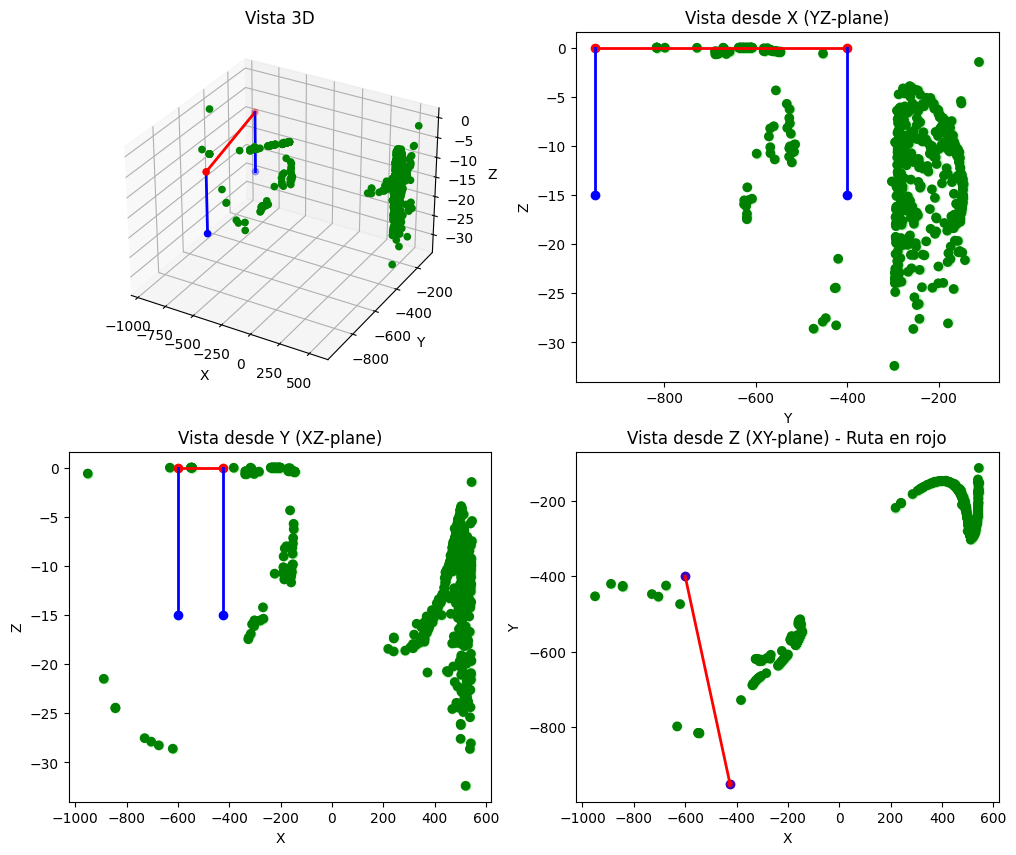


Mapa número = 2


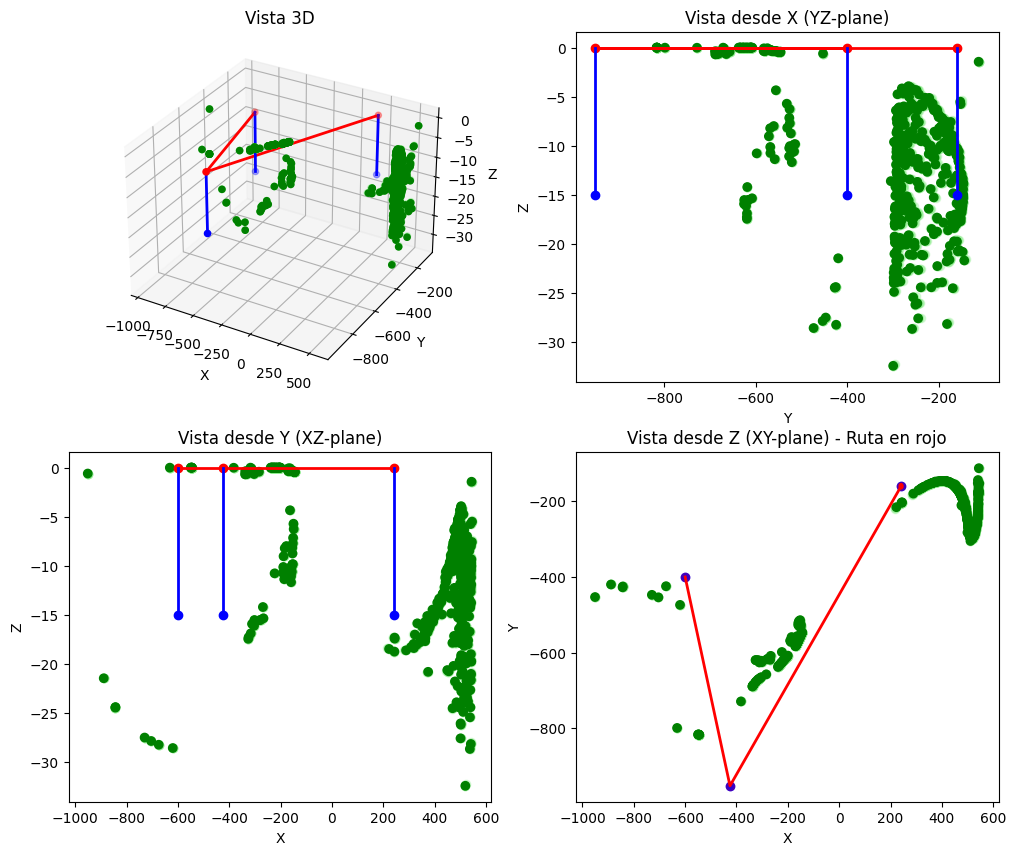


Mapa número = 3


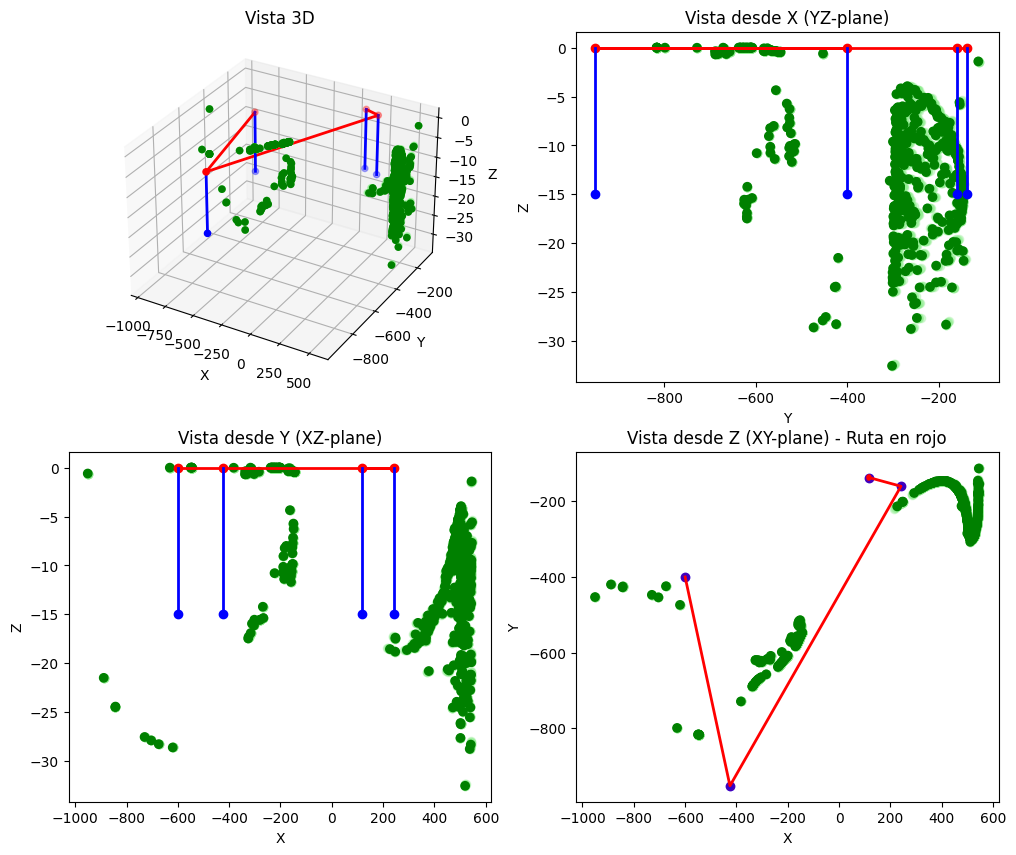


Mapa número = 3


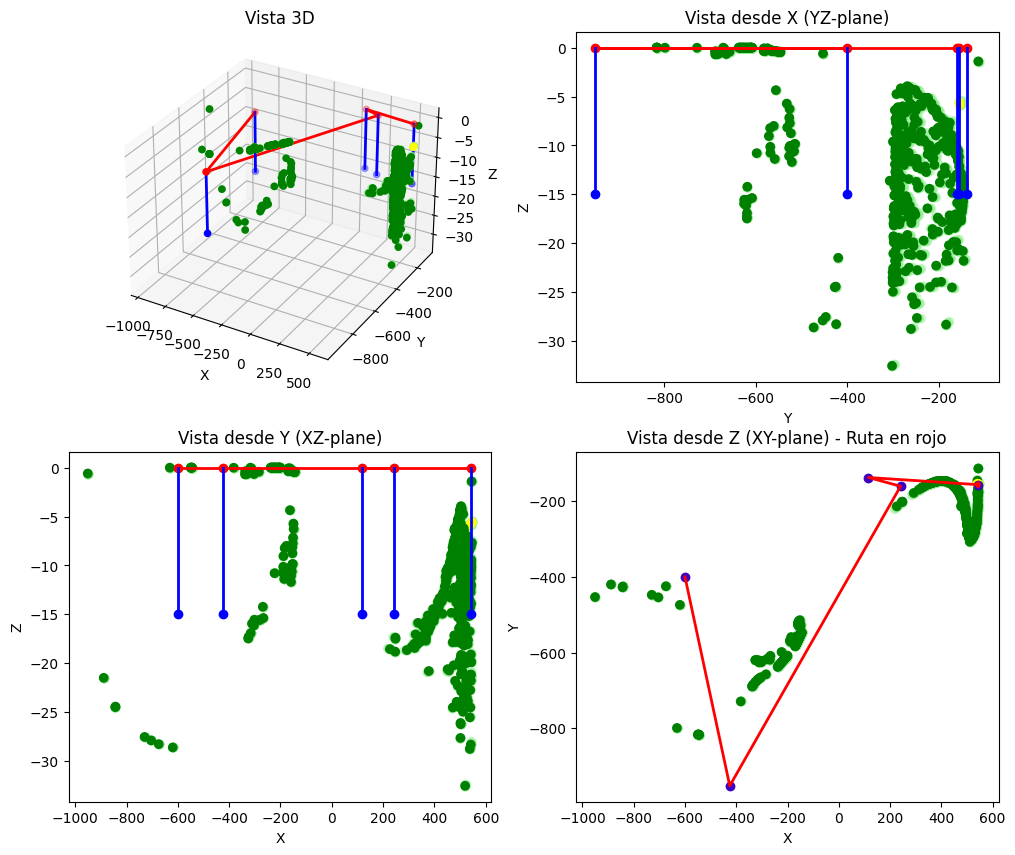


Mapa número = 4


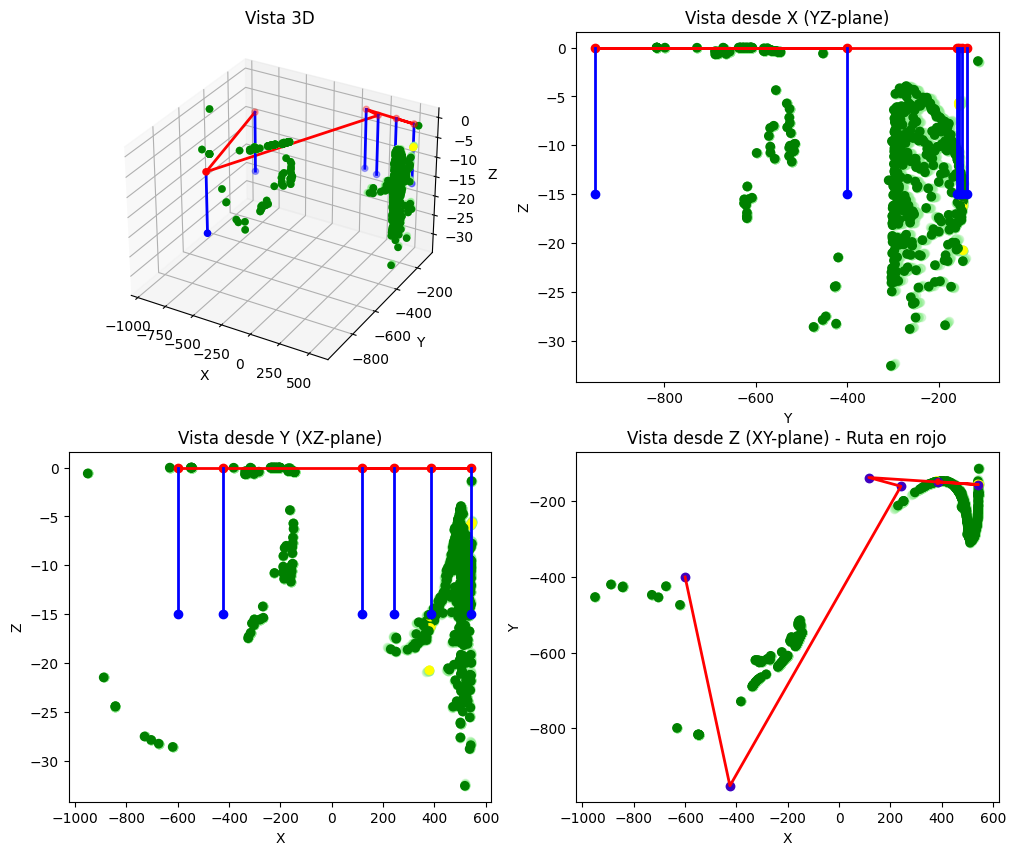


Mapa número = 4


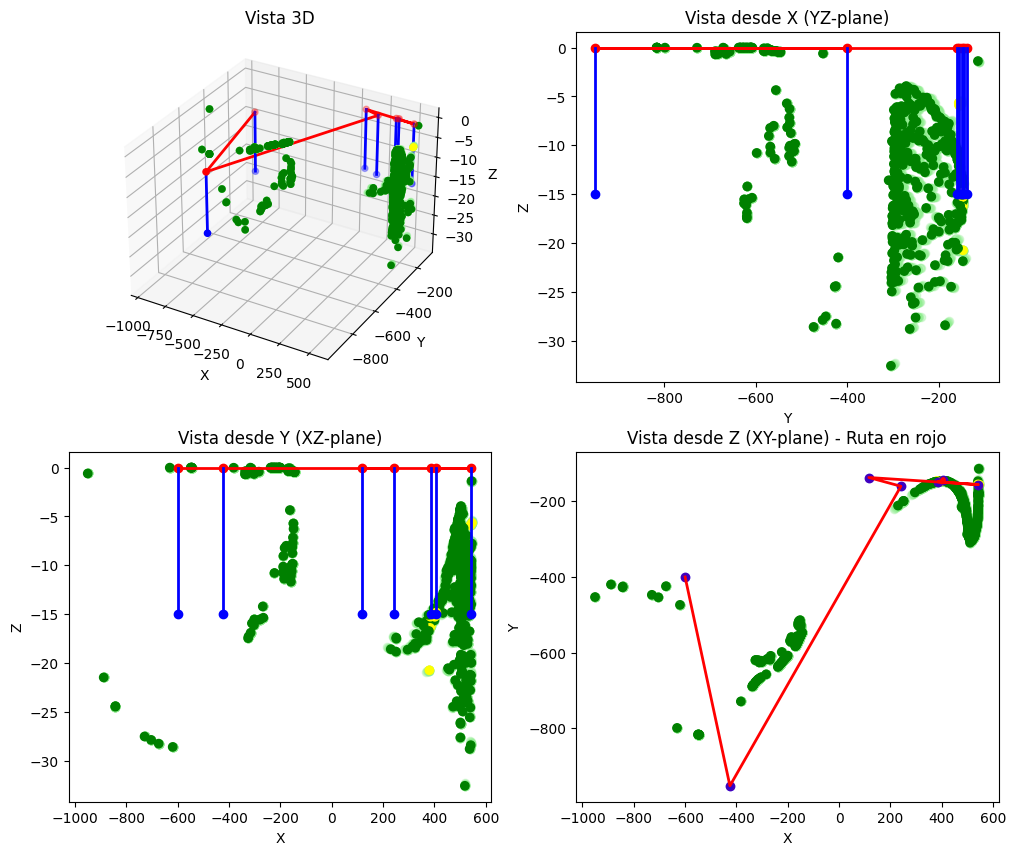


Mapa número = 5


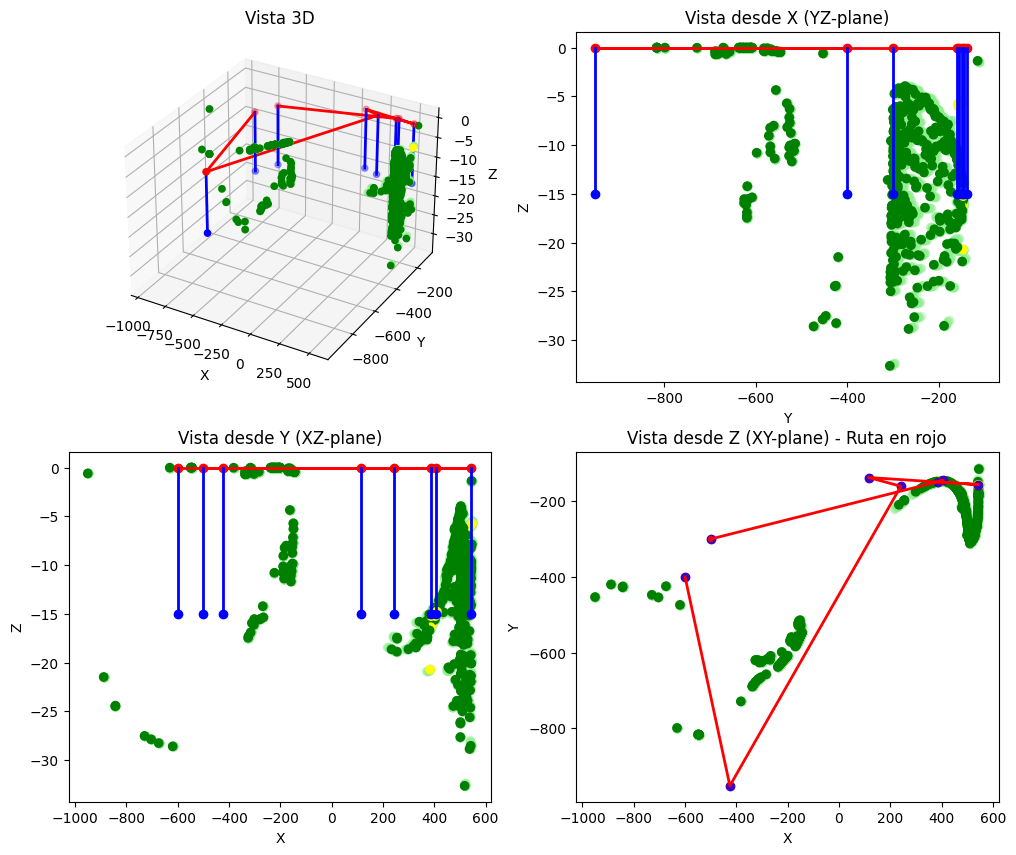

array([0., 0., 0., 0., 0., 0., 0., 0.])

In [22]:
import numpy as np
import matplotlib.pyplot as plt

mapa_mejor = mapa_dinamico_detecciones

tiempos_ruta = np.zeros(int(len(mejor_individuo) / 3))
x = []
y = []
z = []
j = 0
v_media = 1

plt.ion()  # Activar modo interactivo
zeros = []
longitud_recorrido = 0

# Listas para almacenar partículas de instantes anteriores
historico_x = []
historico_y = []
historico_z = []

for i in range(len(recorrido)):
    if i == 0:
        p2 = recorrido[i]
    else:
        p1 = recorrido[i-1]
        p2 = recorrido[i]
        longitud_recorrido += calcular_distancia(p1, p2)
    zeros.append(0)
    tAct = tiempo + longitud_recorrido / (v_media * 60) + t_medida * (i + 1)
    dif_tVec_tAct = np.abs(tVec_min - tAct)
    indice_tVec = np.argmin(dif_tVec_tAct)
    print(f"")
    # Obtener las coordenadas de las partículas
    map_x = xCellLog[indice_tVec, :, 0]
    map_y = xCellLog[indice_tVec, :, 1]
    map_z = xCellLog[indice_tVec, :, 2]
    print(f"Mapa número = {indice_tVec}")
    # Guardar en el histórico
    historico_x.append(map_x)
    historico_y.append(map_y)
    historico_z.append(map_z)
    
    indices_detectados_i = mapa_mejor[i]
    colores = ["yellow" if indices_detectados_i[k] == 1 else 'green' for k in range(len(indices_detectados_i))]
    
    # Agregar el punto actual antes de graficar
    x.append(mejor_individuo[j])
    y.append(mejor_individuo[j+1])
    z.append(mejor_individuo[j+2])
    
    # Crear figura con 4 subgráficos
    fig = plt.figure(figsize=(12, 10))
    
    # 3D View
    ax1 = fig.add_subplot(221, projection='3d')
    for h in range(len(historico_x)):
        alpha_val = 0.3 + 0.7 * (h / len(historico_x))
        ax1.scatter(historico_x[h], historico_y[h], historico_z[h], c='lightgreen', marker='o', alpha=alpha_val)
    ax1.scatter(map_x, map_y, map_z, c=colores, marker='o', alpha=1)
    ax1.scatter(x, y, z, c='b', marker='o')
    ax1.scatter(x, y, zeros, c='r', marker='o')
    ax1.plot(x, y, zeros, c='r', linestyle='-', linewidth=2)
    for k in range(len(x)):
        ax1.plot([x[k], x[k]], [y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title("Vista 3D")
    
    # Vista desde X (YZ-plane)
    ax2 = fig.add_subplot(222)
    for h in range(len(historico_y)):
        alpha_val = 0.3 + 0.7 * (h / len(historico_y))
        ax2.scatter(historico_y[h], historico_z[h], c='lightgreen', marker='o', alpha=alpha_val)
    ax2.scatter(map_y, map_z, c=colores, marker='o', alpha=1)
    ax2.scatter(y, z, c='b', marker='o')
    ax2.scatter(y, zeros, c='red', marker='o')
    ax2.plot(y, zeros, c='r', linestyle='-', linewidth=2)
    for k in range(len(y)):
        ax2.plot([y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)
    ax2.set_xlabel('Y')
    ax2.set_ylabel('Z')
    ax2.set_title("Vista desde X (YZ-plane)")
    
    # Vista desde Y (XZ-plane)
    ax3 = fig.add_subplot(223)
    for h in range(len(historico_x)):
        alpha_val = 0.3 + 0.7 * (h / len(historico_x))
        ax3.scatter(historico_x[h], historico_z[h], c='lightgreen', marker='o', alpha=alpha_val)
    ax3.scatter(map_x, map_z, c=colores, marker='o', alpha=1)
    ax3.scatter(x, z, c='b', marker='o')
    ax3.scatter(x, zeros, c='red', marker='o')
    ax3.plot(x, zeros, c='r', linestyle='-', linewidth=2)
    for k in range(len(x)):
        ax3.plot([x[k], x[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)
    ax3.set_xlabel('X')
    ax3.set_ylabel('Z')
    ax3.set_title("Vista desde Y (XZ-plane)")
    
    # Vista desde Z (XY-plane)
    ax4 = fig.add_subplot(224)
    for h in range(len(historico_x)):
        alpha_val = 0.3 + 0.7 * (h / len(historico_x))
        ax4.scatter(historico_x[h], historico_y[h], c='lightgreen', marker='o', alpha=alpha_val)
    ax4.scatter(map_x, map_y, c=colores, marker='o', alpha=1)
    ax4.scatter(x, y, c='b', marker='o')
    ax4.scatter(x, y, c='red', marker='o', alpha=0.2)
    ax4.plot(x, y, c='r', linestyle='-', linewidth=2)
    radio = 5
    circle = plt.Circle((x[-1], y[-1]), radio, color='r', fill=False, linewidth=2)
    ax4.add_patch(circle)
    # for idx, (xi, yi, zi) in enumerate(zip(x, y, z)):
    #     ax4.text(xi, yi, str(idx), color='blue', fontsize=12, fontweight='bold')
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.set_title("Vista desde Z (XY-plane) - Ruta en rojo")

    # if(i < len(tiempos_ruta)-1 ):
    #     ax4.set_xlim(min(x[-1] - 100, min(x)), max(x[-1] + 100, max(x)))
    #     ax4.set_ylim(min(y[-1] - 100, min(y)), max(y[-1] + 100, max(y)))
    # else:
    #     ax4.set_xlim(min(x[0] - 100, min(x)), max(x[0] + 100, max(x)))
    #     ax4.set_ylim(min(y[0] - 100, min(y)), max(y[0] + 100, max(y)))

    # # ax4.set_xlim(-200, 50)
    # # ax4.set_ylim(-200, -50)  
    
    plt.show()
    plt.pause(0.1)
    
    j += 3

tiempos_ruta


In [23]:
# best_idx = np.argmin(F[:, 1])  # Encuentra el índice del menor valor en la columna 1

# mejor_individuo = X[best_idx]  # Extrae la solución correspondiente

weights = np.array([0.10, 0.80, 0.10])  # Ajusta según tus preferencias
scores = (F * weights).sum(axis=1)  # Calcula la función agregada
best_idx = np.argmin(scores)  # Minimización
mejor_individuo = X[best_idx]

print(f"best_idx {best_idx}")

#====== Si se quieren poner umbrales ======# 
# filtered_idx = np.where((F[:, 0] <= 0.5) & (F[:, 1] <= 0.3))[0]
# best_idx = filtered_idx[np.argmin(F[filtered_idx, 2])]  # Minimiza el tercer objetivo
# best_solution = pop[best_idx]
#=========================================#

#Ahora saco la evolución de las detecciones al igual que en la evaluacion
# Iterar sobre el recorrido y calcular la longitud total
for i in range(2, len(mejor_individuo), 3):
    #print(i)
    mejor_individuo[i]=-15

recorrido = [mejor_individuo[i:i+3] for i in range(0, len(mejor_individuo), 3)]

tiempo=tVec_min[0,0] #Tomamos como orgien el tiempo inicial de la simulación
indices_detectados = np.zeros(len(mapa_particulas[1]))
indices_detectados_ant = np.zeros(len(mapa_particulas[1]))
indices_eliminadas = np.zeros(len(mapa_particulas[1]))
pesos_gaussianos_i =  np.zeros(len(mapa_particulas[1]))
aportaciones = np.zeros(len(mapa_particulas[1]))
indices_repetidas = np.zeros(len(mapa_particulas[1])) 
longitud_recorrido = 0
mapa_dinamico_detecciones = np.zeros((len(recorrido), len(indices_detectados)))
detecciones_totales = 0
t_medida = 8 #min
for i in range(len(recorrido)):
    deteccion = 0
    if (i==0):
        p2 = recorrido[i]
    else:
        p1 = recorrido[i-1]
        p2 = recorrido[i]
        longitud_recorrido += calcular_distancia(p1, p2)

    tAct = tiempo + longitud_recorrido/(v_media*60)+t_medida*(i+1) #El i+i es para sumar el tiempo de cada vez que se ha medido
    dif_tVec_tAct = np.abs(tVec_min - tAct) #Hacemos el absoluto para buscar el 0, es decir, el más cercano al instante actual
    indice_tVec = np.argmin(dif_tVec_tAct) #El índice que tengo que buscar en 
    
    #print(f"tAct: {tAct}, tVec: {tVec_min}")
    #print(f"Diferencia absoluta: {dif_tVec_tAct}")
    #print(f"Índice del valor más cercano: {indice_tVec}")
    
    #Hay que ver si en el cambio de tVec se han modificado los ID detectados. 
    #Para ello simplemente creamos un nuevo indices_detectados en caso de que haya cambiado el mapa actualizando las posiciones de los nuevos indices
    if(indice_tVec != indice_tVec_ant):
        #Creamos un diccionario de detecciones
        id_detectados = {id_: det for id_, det in zip(IDLogs[indice_tVec_ant], indices_detectados) if not np.isnan(id_)}
        id_detectados_t2 = np.array([id_detectados.get(id_, 0) for id_ in IDLogs[indice_tVec]])
        indices_detectados = (id_detectados_t2 > 0).astype(int)
    # Actualizar el mapa y contar las partículas detectadas
    
    indices_detectados, indices_eliminadas = eliminar_particulas_en_rango(xCellLog[indice_tVec, :, :], p2, rango_deteccion, indices_detectados, indices_eliminadas)

    indice_tVec_ant = indice_tVec
    mapa_dinamico_detecciones[i] = indices_detectados
    #print(f"Indices detectados = {np.sum(indices_detectados)}")
detecciones_totales = np.sum(indices_detectados)
#print(f"Detecciones totales = {detecciones_totales}")
#print(f"Tiempo total = {(tAct-tiempo)*60}")

best_idx 242



Mapa número = 0


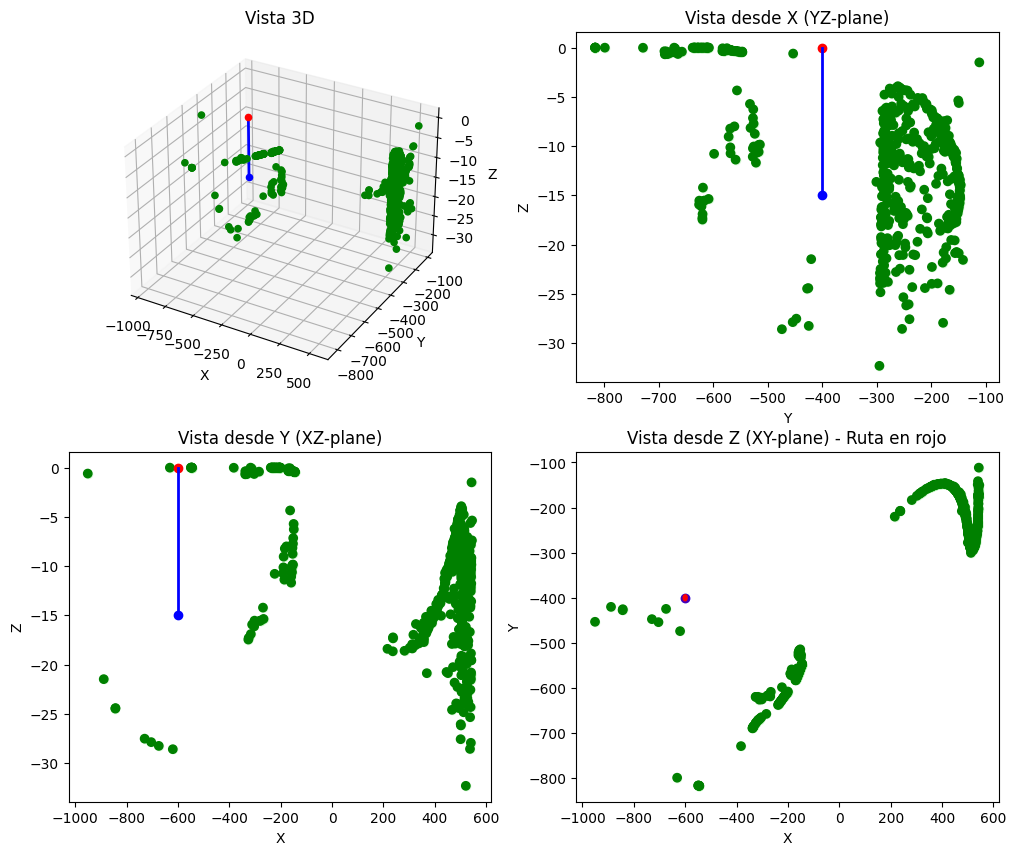


Mapa número = 2


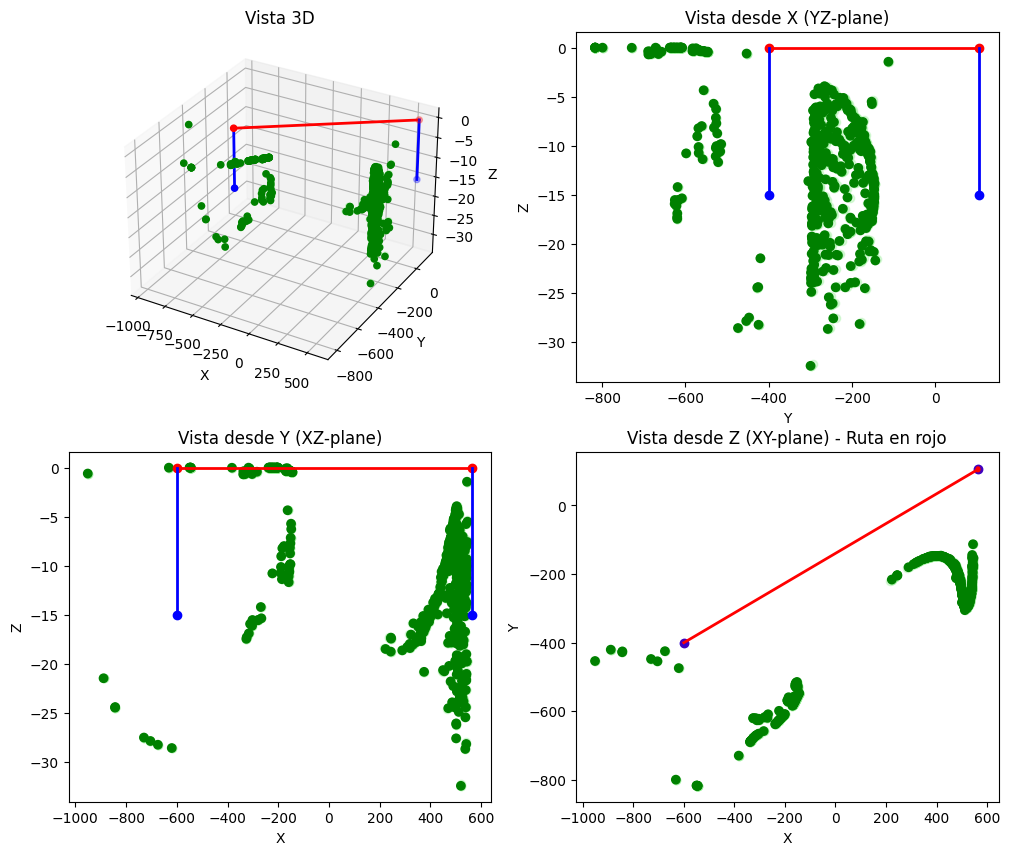


Mapa número = 2


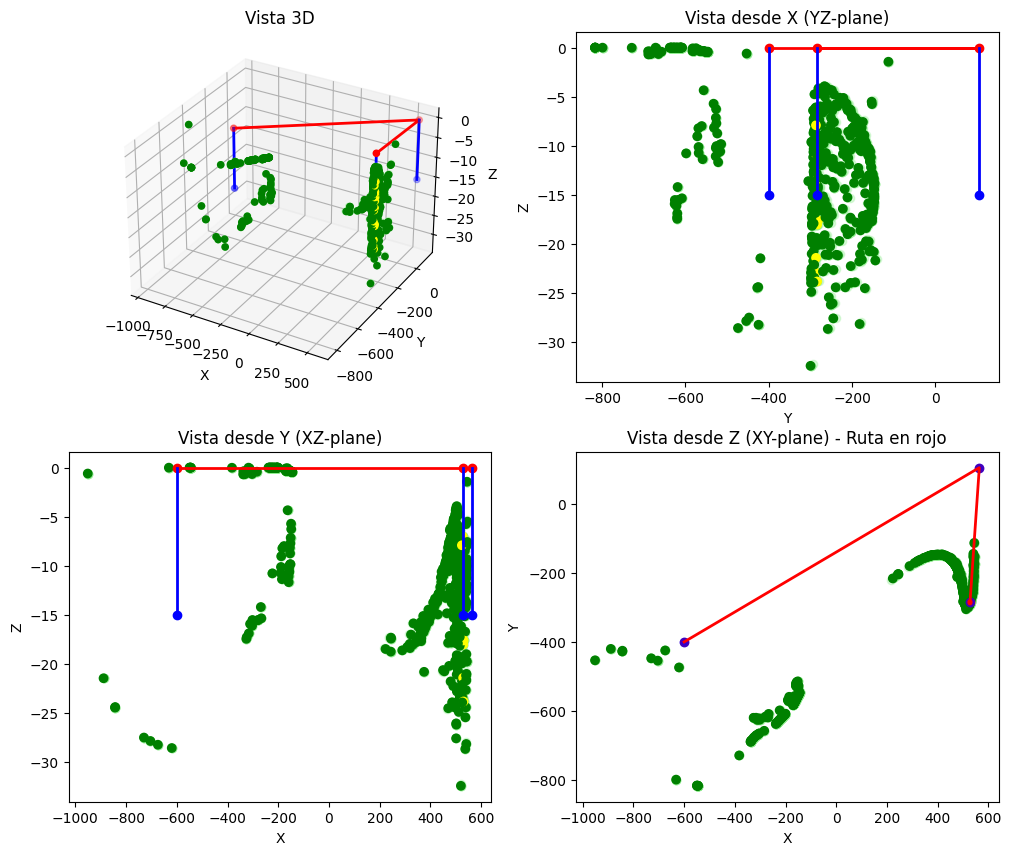


Mapa número = 3


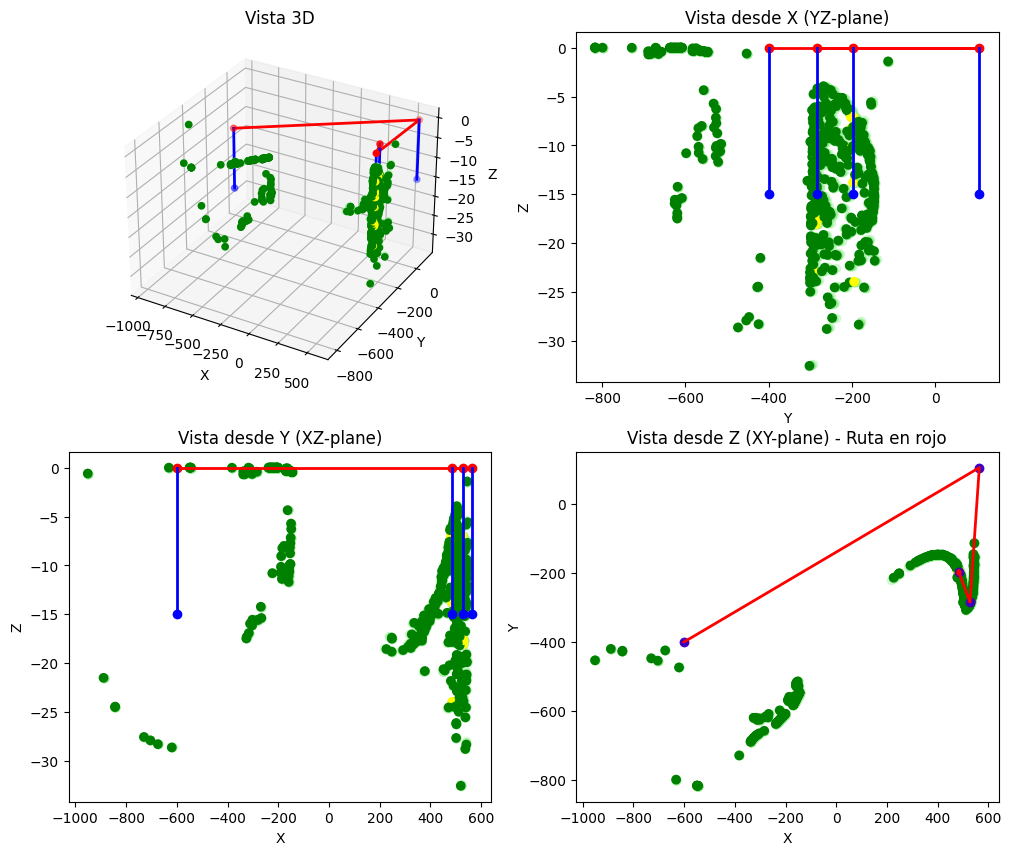


Mapa número = 3


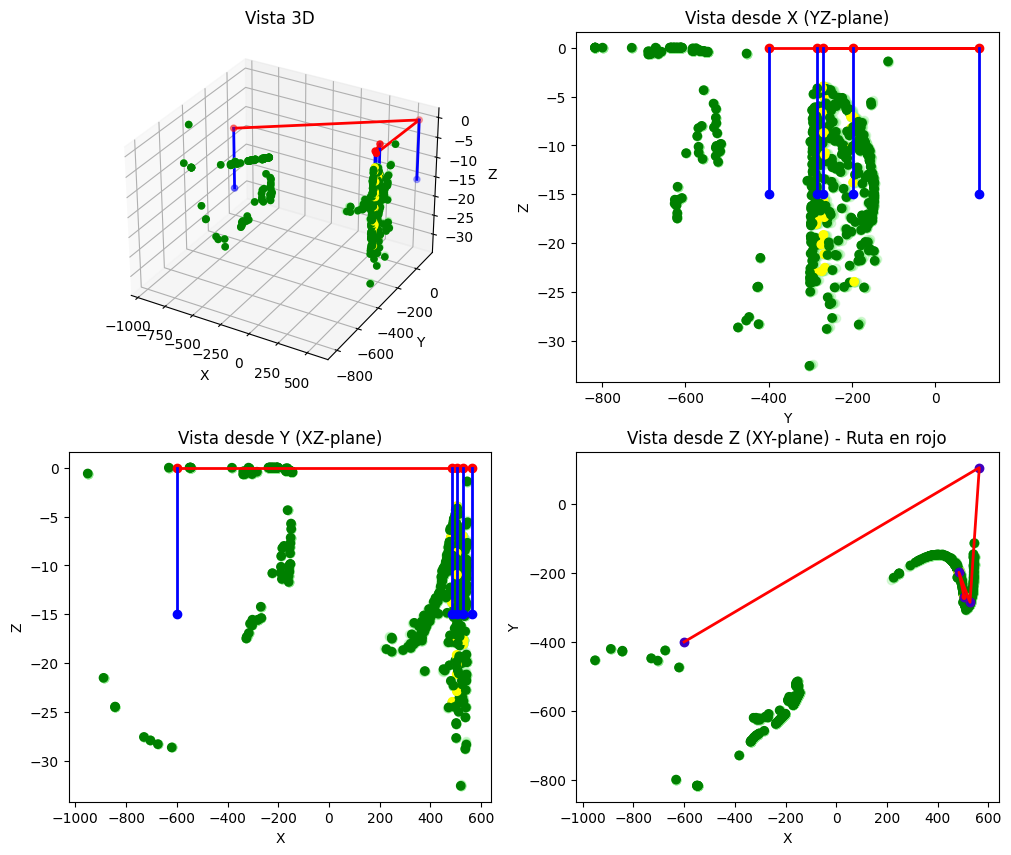


Mapa número = 3


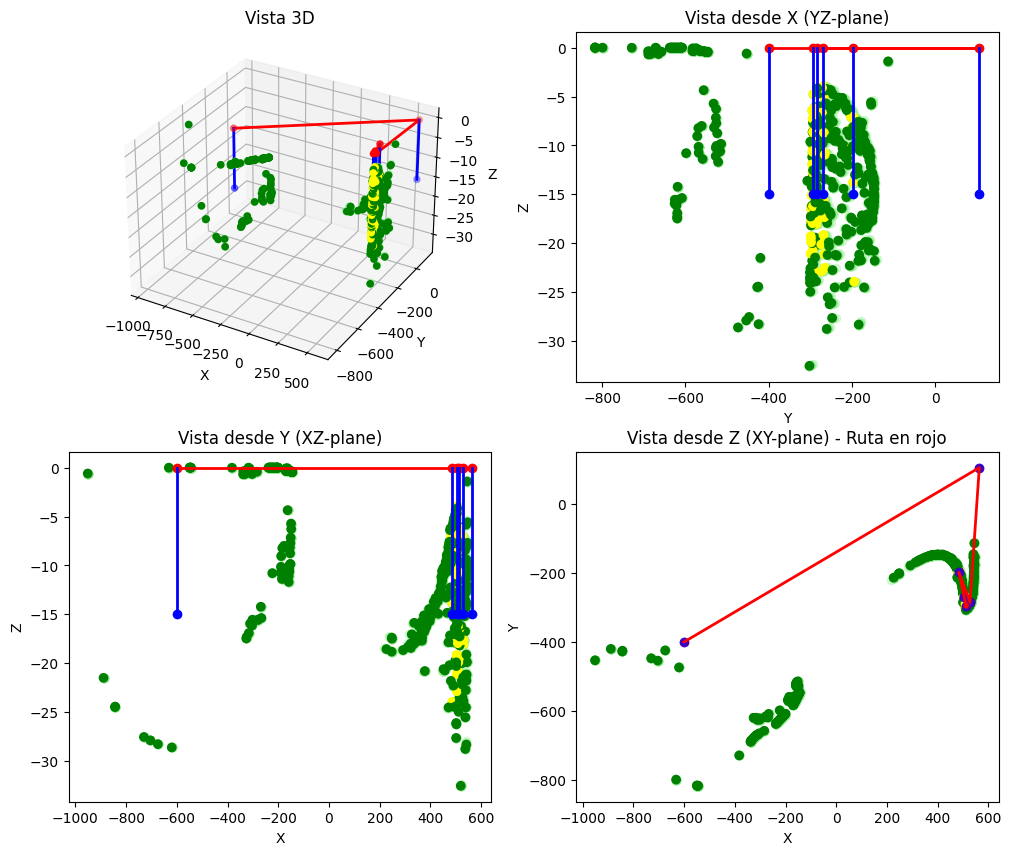


Mapa número = 4


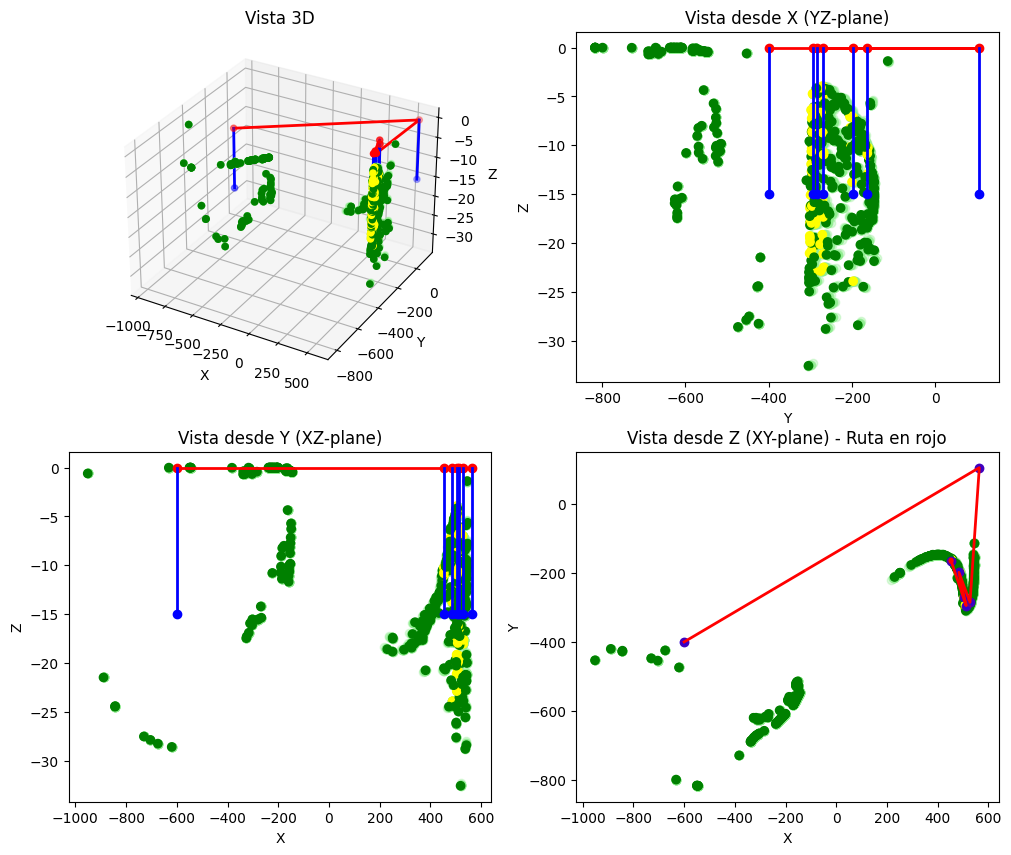


Mapa número = 5


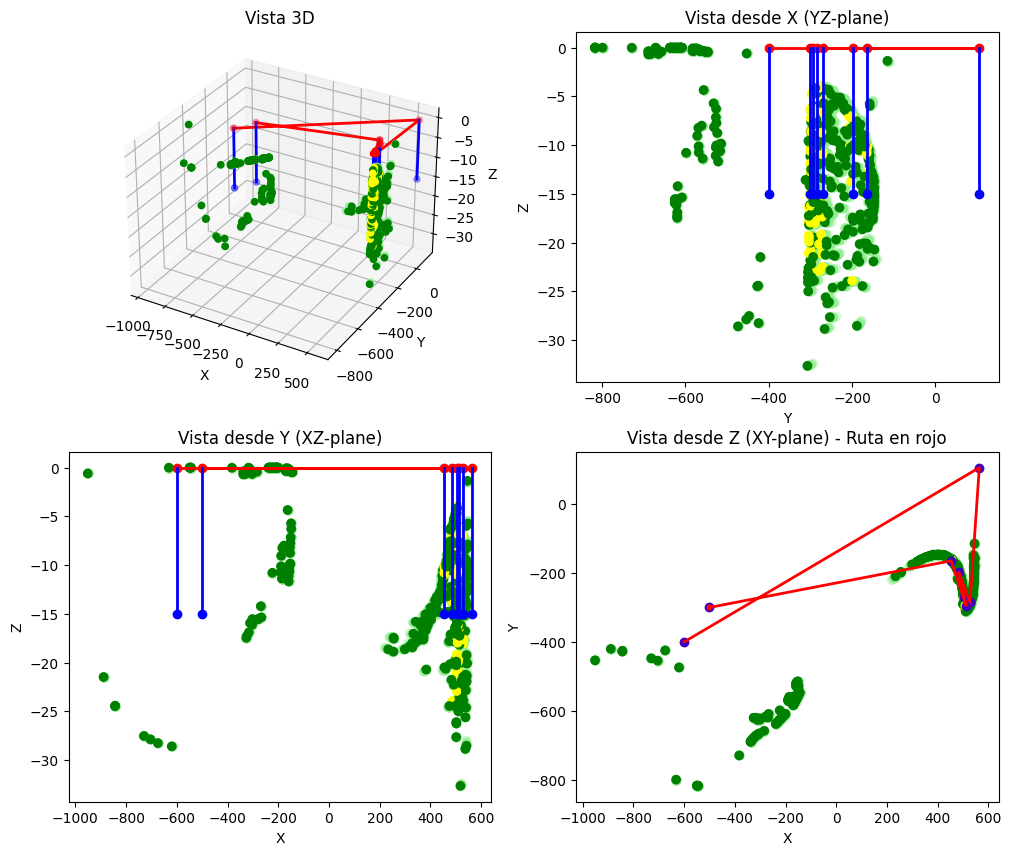

array([0., 0., 0., 0., 0., 0., 0., 0.])

In [24]:
import numpy as np
import matplotlib.pyplot as plt

mapa_mejor = mapa_dinamico_detecciones

tiempos_ruta = np.zeros(int(len(mejor_individuo) / 3))
x = []
y = []
z = []
j = 0
v_media = 1

plt.ion()  # Activar modo interactivo
zeros = []
longitud_recorrido = 0

# Listas para almacenar partículas de instantes anteriores
historico_x = []
historico_y = []
historico_z = []

for i in range(len(recorrido)):
    if i == 0:
        p2 = recorrido[i]
    else:
        p1 = recorrido[i-1]
        p2 = recorrido[i]
        longitud_recorrido += calcular_distancia(p1, p2)
    zeros.append(0)
    tAct = tiempo + longitud_recorrido / (v_media * 60) + t_medida * (i + 1)
    dif_tVec_tAct = np.abs(tVec_min - tAct)
    indice_tVec = np.argmin(dif_tVec_tAct)
    print(f"")
    # Obtener las coordenadas de las partículas
    map_x = xCellLog[indice_tVec, :, 0]
    map_y = xCellLog[indice_tVec, :, 1]
    map_z = xCellLog[indice_tVec, :, 2]
    print(f"Mapa número = {indice_tVec}")
    # Guardar en el histórico
    historico_x.append(map_x)
    historico_y.append(map_y)
    historico_z.append(map_z)
    
    indices_detectados_i = mapa_mejor[i]
    colores = ["yellow" if indices_detectados_i[k] == 1 else 'green' for k in range(len(indices_detectados_i))]
    
    # Agregar el punto actual antes de graficar
    x.append(mejor_individuo[j])
    y.append(mejor_individuo[j+1])
    z.append(mejor_individuo[j+2])
    
    # Crear figura con 4 subgráficos
    fig = plt.figure(figsize=(12, 10))
    
    # 3D View
    ax1 = fig.add_subplot(221, projection='3d')
    for h in range(len(historico_x)):
        alpha_val = 0.3 + 0.7 * (h / len(historico_x))
        ax1.scatter(historico_x[h], historico_y[h], historico_z[h], c='lightgreen', marker='o', alpha=alpha_val)
    ax1.scatter(map_x, map_y, map_z, c=colores, marker='o', alpha=1)
    ax1.scatter(x, y, z, c='b', marker='o')
    ax1.scatter(x, y, zeros, c='r', marker='o')
    ax1.plot(x, y, zeros, c='r', linestyle='-', linewidth=2)
    for k in range(len(x)):
        ax1.plot([x[k], x[k]], [y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title("Vista 3D")
    
    # Vista desde X (YZ-plane)
    ax2 = fig.add_subplot(222)
    for h in range(len(historico_y)):
        alpha_val = 0.3 + 0.7 * (h / len(historico_y))
        ax2.scatter(historico_y[h], historico_z[h], c='lightgreen', marker='o', alpha=alpha_val)
    ax2.scatter(map_y, map_z, c=colores, marker='o', alpha=1)
    ax2.scatter(y, z, c='b', marker='o')
    ax2.scatter(y, zeros, c='red', marker='o')
    ax2.plot(y, zeros, c='r', linestyle='-', linewidth=2)
    for k in range(len(y)):
        ax2.plot([y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)
    ax2.set_xlabel('Y')
    ax2.set_ylabel('Z')
    ax2.set_title("Vista desde X (YZ-plane)")
    
    # Vista desde Y (XZ-plane)
    ax3 = fig.add_subplot(223)
    for h in range(len(historico_x)):
        alpha_val = 0.3 + 0.7 * (h / len(historico_x))
        ax3.scatter(historico_x[h], historico_z[h], c='lightgreen', marker='o', alpha=alpha_val)
    ax3.scatter(map_x, map_z, c=colores, marker='o', alpha=1)
    ax3.scatter(x, z, c='b', marker='o')
    ax3.scatter(x, zeros, c='red', marker='o')
    ax3.plot(x, zeros, c='r', linestyle='-', linewidth=2)
    for k in range(len(x)):
        ax3.plot([x[k], x[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)
    ax3.set_xlabel('X')
    ax3.set_ylabel('Z')
    ax3.set_title("Vista desde Y (XZ-plane)")
    
    # Vista desde Z (XY-plane)
    ax4 = fig.add_subplot(224)
    for h in range(len(historico_x)):
        alpha_val = 0.3 + 0.7 * (h / len(historico_x))
        ax4.scatter(historico_x[h], historico_y[h], c='lightgreen', marker='o', alpha=alpha_val)
    ax4.scatter(map_x, map_y, c=colores, marker='o', alpha=1)
    ax4.scatter(x, y, c='b', marker='o')
    ax4.scatter(x, y, c='red', marker='o', alpha=0.2)
    ax4.plot(x, y, c='r', linestyle='-', linewidth=2)
    radio = 5
    circle = plt.Circle((x[-1], y[-1]), radio, color='r', fill=False, linewidth=2)
    ax4.add_patch(circle)
    # for idx, (xi, yi, zi) in enumerate(zip(x, y, z)):
    #     ax4.text(xi, yi, str(idx), color='blue', fontsize=12, fontweight='bold')
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.set_title("Vista desde Z (XY-plane) - Ruta en rojo")

    # if(i < len(tiempos_ruta)-1 ):
    #     ax4.set_xlim(min(x[-1] - 100, min(x)), max(x[-1] + 100, max(x)))
    #     ax4.set_ylim(min(y[-1] - 100, min(y)), max(y[-1] + 100, max(y)))
    # else:
    #     ax4.set_xlim(min(x[0] - 100, min(x)), max(x[0] + 100, max(x)))
    #     ax4.set_ylim(min(y[0] - 100, min(y)), max(y[0] + 100, max(y)))

    # # ax4.set_xlim(-200, 50)
    # # ax4.set_ylim(-200, -50)  
    
    plt.show()
    plt.pause(0.1)
    
    j += 3

tiempos_ruta
